<a href="https://colab.research.google.com/github/Sakshii248/world-happiness-analysis/blob/main/world_happiness_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

dict_keys(['2020', '2021', '2022', '2023', '2024'])


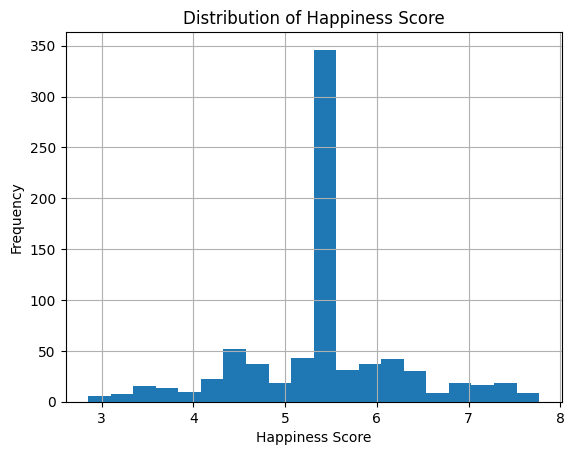

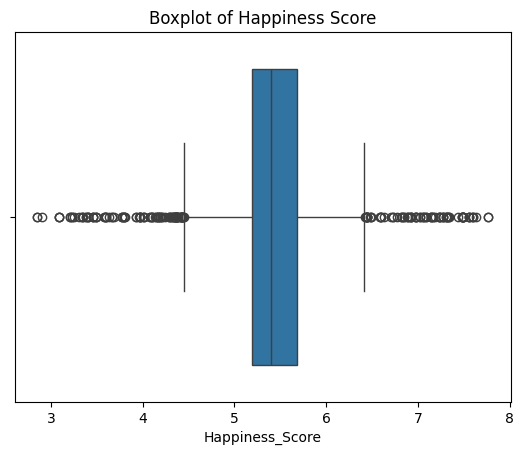

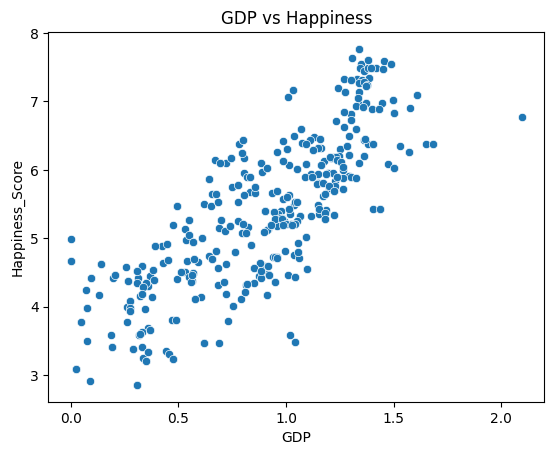

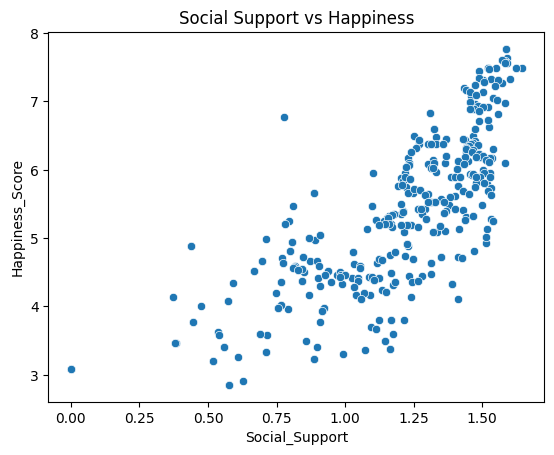

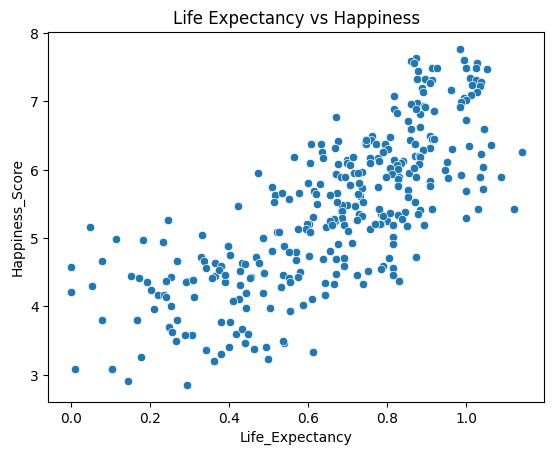

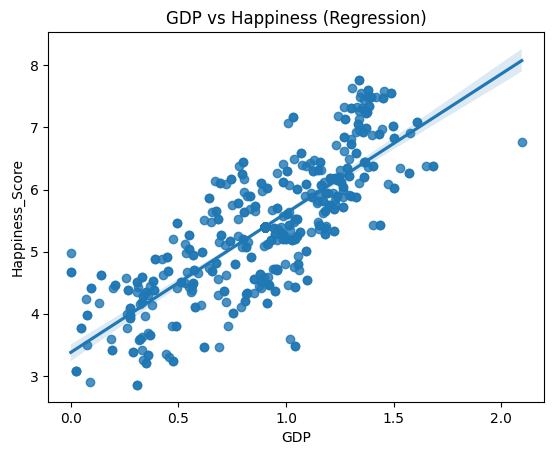

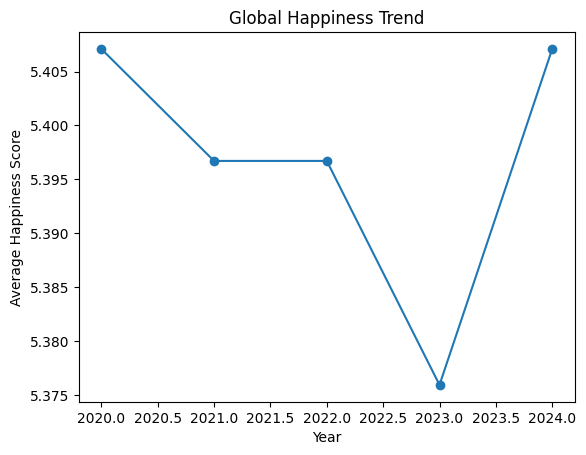

(Year          2020      2021      2022   2023   2024  Change
 Country                                                     
 Afghanistan  3.203  5.396703  5.396703  3.632  3.203     0.0
 Albania      4.719  5.396703  5.396703  4.586  4.719     0.0
 Algeria      5.211  5.396703  5.396703  5.295  5.211     0.0
 Argentina    6.086  5.396703  5.396703  6.388  6.086     0.0
 Armenia      4.559  5.396703  5.396703  4.321  4.559     0.0,
 Year          2020      2021      2022   2023   2024  Change
 Country                                                     
 Afghanistan  3.203  5.396703  5.396703  3.632  3.203     0.0
 Albania      4.719  5.396703  5.396703  4.586  4.719     0.0
 Algeria      5.211  5.396703  5.396703  5.295  5.211     0.0
 Argentina    6.086  5.396703  5.396703  6.388  6.086     0.0
 Armenia      4.559  5.396703  5.396703  4.321  4.559     0.0)

In [45]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#load dataset
url = "https://raw.githubusercontent.com/Sakshii248/world-happiness-analysis/main/data/pone.0322287.s001.xlsx"
all_sheets = pd.read_excel(url, sheet_name=None)
print(all_sheets.keys())

#clean + combine data
def clean_modern(df, year):
    df = df.copy()

    df = df.rename(columns={
        'Country or region': 'Country',
        'Score': 'Happiness_Score',
        'GDP per capita': 'GDP',
        'Social support': 'Social_Support',
        'Healthy life expectancy': 'Life_Expectancy',
        'Freedom to make life choices': 'Freedom',
        'Perceptions of corruption': 'Corruption'
    })

    df['Year'] = year

    return df


df_list = []

for year, df in all_sheets.items():
    df_clean = clean_modern(df, int(year))
    df_list.append(df_clean)

df_all = pd.concat(df_list, ignore_index=True)

df_all.head()

#basic cleaning
df_cleaned = df_all.copy()

# Fill missing values (excluding Year)
numeric_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = numeric_cols.drop('Year')

for col in numeric_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mean())

# Check missing values
df_cleaned.isnull().sum()

#summary statistics
df_cleaned.describe()

#histogram
df_cleaned['Happiness_Score'].hist(bins=20)

plt.title("Distribution of Happiness Score")
plt.xlabel("Happiness Score")
plt.ylabel("Frequency")

plt.show()

#boxplot
sns.boxplot(x=df_cleaned['Happiness_Score'])

plt.title("Boxplot of Happiness Score")

plt.show()

#correlation heatmap
"""numeric_df = df_cleaned.select_dtypes(include=['float64', 'int64'])

# Remove Year
numeric_df = numeric_df.drop(columns=['Year'])

corr = numeric_df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()"""

#GDP vs happiness
sns.scatterplot(x='GDP', y='Happiness_Score', data=df_cleaned)

plt.title("GDP vs Happiness")

plt.show()

#social support vs happiness
sns.scatterplot(x='Social_Support', y='Happiness_Score', data=df_cleaned)

plt.title("Social Support vs Happiness")

plt.show()

#life expectancy vs happiness
sns.scatterplot(x='Life_Expectancy', y='Happiness_Score', data=df_cleaned)

plt.title("Life Expectancy vs Happiness")

plt.show()

#regression plot
sns.regplot(x='GDP', y='Happiness_Score', data=df_cleaned)

plt.title("GDP vs Happiness (Regression)")

plt.show()

#time series(global trend)
yearly_avg = df_cleaned.groupby('Year')['Happiness_Score'].mean()

yearly_avg.plot(marker='o')

plt.title("Global Happiness Trend")
plt.xlabel("Year")
plt.ylabel("Average Happiness Score")

plt.show()

#country improvent
country_trend = df_cleaned.pivot(index='Country', columns='Year', values='Happiness_Score')

country_trend = country_trend.dropna()

country_trend['Change'] = country_trend[2024] - country_trend[2020]

top_improved = country_trend.sort_values('Change', ascending=False).head(5)
top_declined = country_trend.sort_values('Change').head(5)

top_improved, top_declined

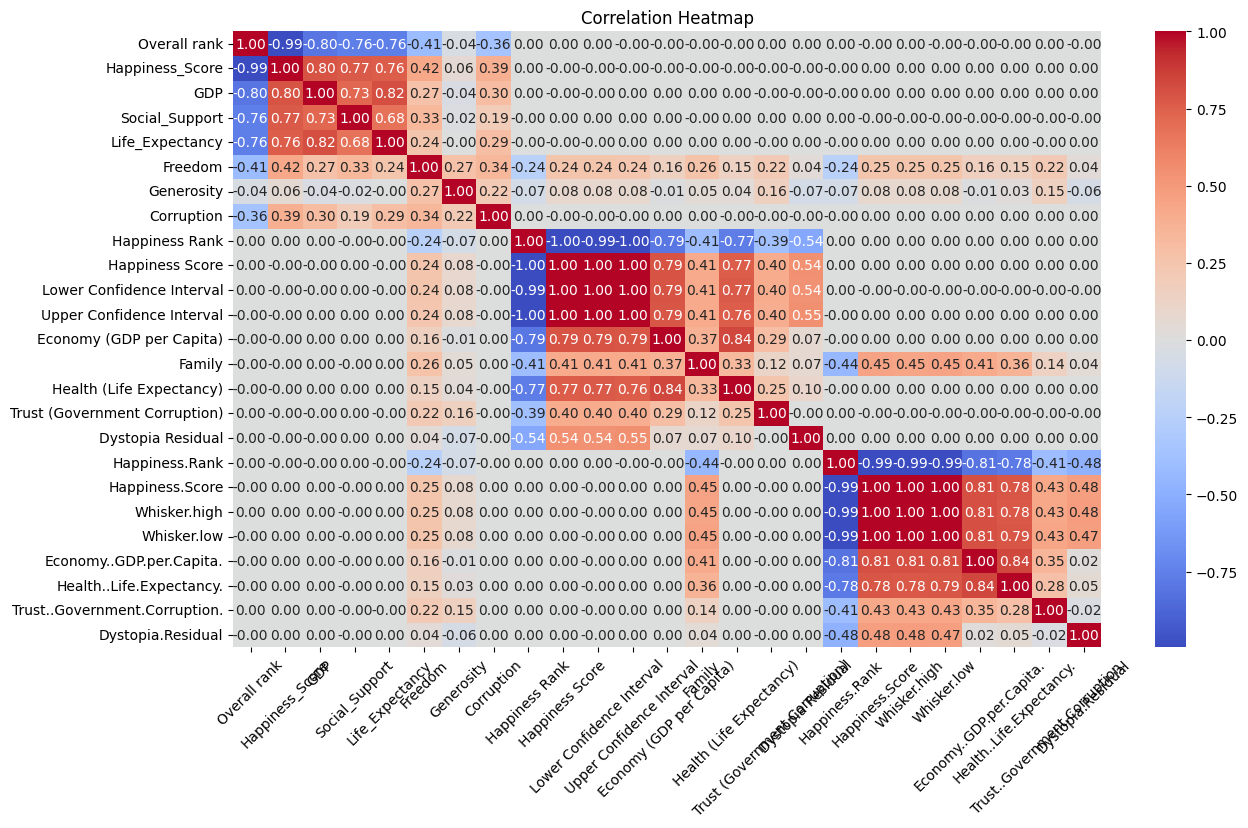

In [46]:
#more defined heatmap
numeric_df = df_cleaned.select_dtypes(include=['float64', 'int64'])
numeric_df = numeric_df.drop(columns=['Year'])

corr = numeric_df.corr()

plt.figure(figsize=(14,8))

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

In [47]:
#basic machine learning model
#prepare data
from sklearn.model_selection import train_test_split

# Features (inputs)
X = df_cleaned[['GDP', 'Social_Support', 'Life_Expectancy', 'Freedom', 'Generosity', 'Corruption']]

# Target (output)
y = df_cleaned['Happiness_Score']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#train model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

#predictions
y_pred = model.predict(X_test)

#evaluate model
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2 Score:", r2)
print("MSE:", mse)

#feature importance
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_
})

coefficients.sort_values(by='Importance', ascending=False)

R2 Score: 0.7561448806726739
MSE: 0.2031846697691003


,Feature,Importance
5,Corruption,1.758378
1,Social_Support,1.287075
2,Life_Expectancy,1.051545
3,Freedom,0.766602
0,GDP,0.725041
4,Generosity,0.043770
